In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000


In [4]:
def build_model(model_type):
    model = keras.Sequential()
    model.add(layers.Embedding(max_features, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(layers.LSTM(128))
    elif model_type == "GRU":
        model.add(layers.GRU(128))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [5]:
models = {}
histories = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_name}...")
    model = build_model(model_name)
    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)
    models[model_name] = model
    histories[model_name] = history


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 137ms/step - accuracy: 0.5746 - loss: 0.6674 - val_accuracy: 0.6148 - val_loss: 0.6373
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - accuracy: 0.7609 - loss: 0.5008 - val_accuracy: 0.7552 - val_loss: 0.5059
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.8201 - loss: 0.4012 - val_accuracy: 0.7048 - val_loss: 0.5658

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 504ms/step - accuracy: 0.7438 - loss: 0.5015 - val_accuracy: 0.8472 - val_loss: 0.3657
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 503ms/step - accuracy: 0.8836 - loss: 0.2973 - val_accuracy: 0.8606 - val_loss: 0.3334
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 168s 536ms/step - accuracy: 0.9208 - loss: 0.2088 - val_accuracy: 0.8600 - val_loss: 0.3515

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 164s 514ms/step - accuracy: 0.7394 - loss: 0.5100 - val_accuracy: 0.7930 - val_loss: 0.4467
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 508ms/step - accu

In [6]:
results = {}

for model_name, model in models.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[model_name] = acc
    print(f"{model_name} Test Accuracy: {acc:.4f}")

RNN Test Accuracy: 0.7092
LSTM Test Accuracy: 0.8602
GRU Test Accuracy: 0.8622


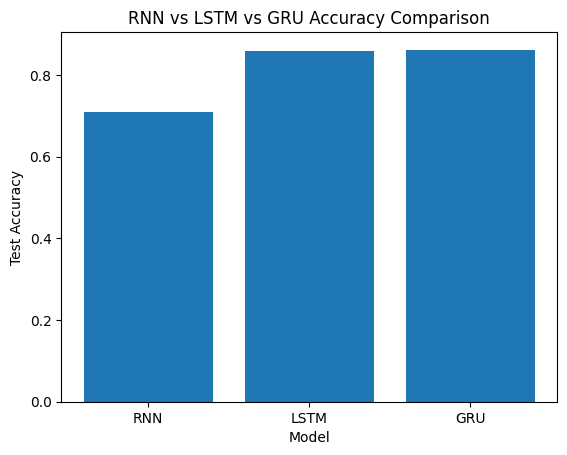

In [7]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()